# 🟡 Project - Heart Disease with XGBoost (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

## Business question
Screen heart disease (`data/heart.csv`) with early-stopped boosting; tune a
compact grid; keep the recall-first clinical lens.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             recall_score, f1_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

heart = pd.read_csv(ML_ROOT / "data" / "heart.csv")   # keep target for EDA

## 3. EDA quick pass

missing: 0 | balance: {1: 0.545, 0: 0.455}


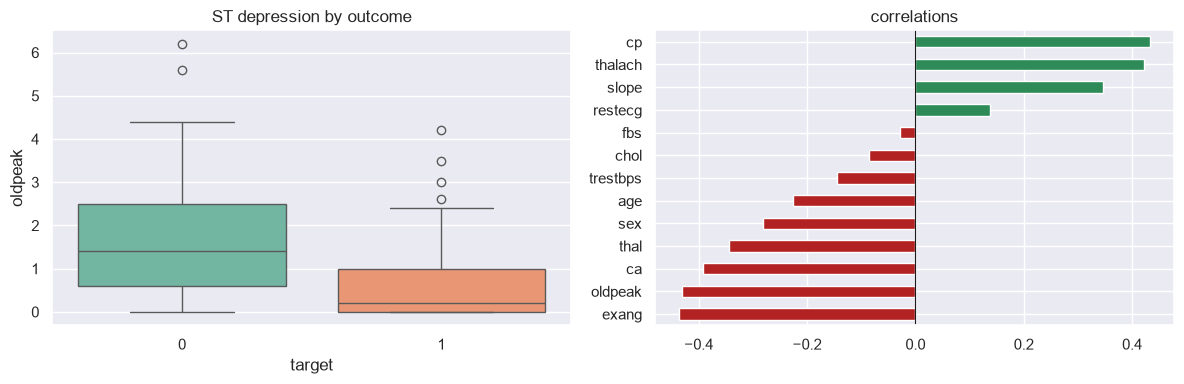

In [2]:
print("missing:", heart.isna().sum().sum(),
      "| balance:", heart.target.value_counts(normalize=True).round(3).to_dict())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=heart, x="target", y="oldpeak", ax=axes[0],
            palette="Set2", hue="target", legend=False)
axes[0].set_title("ST depression by outcome")
corr = heart.corr()["target"].drop("target").sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in corr]
corr.plot(kind="barh", color=colors, ax=axes[1])
axes[1].axvline(0, c="k", lw=.8); axes[1].set_title("correlations")
plt.tight_layout(); plt.show()

## 5. Model training - recall-oriented grid

best: {'learning_rate': 0.05, 'max_depth': 2} | stopped @ 112

test acc 0.737 | disease-recall 0.805 | F1 0.767


CV recall : 0.896


,pred healthy,pred diseased
true healthy,23,12
true diseased,8,33


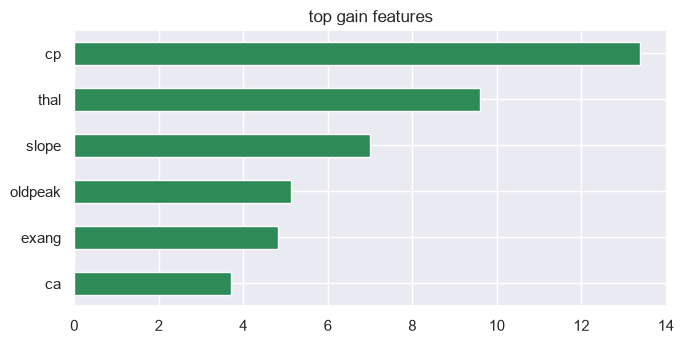

In [3]:
# split AFTER eda so plots could use the label column
y = heart.pop("target").values
X_tr, X_te, y_tr, y_te = train_test_split(
    heart.values.astype(float), y, test_size=.25,
    random_state=42, stratify=y)

grid = GridSearchCV(
    XGBClassifier(n_estimators=400, early_stopping_rounds=40,
                  eval_metric="logloss", random_state=42),
    {"max_depth": [2, 3, 4], "learning_rate": [0.05, 0.1]},
    cv=3, scoring="recall", n_jobs=-1)

# eval_set must ride along for early stopping inside CV folds:
fit_params = {"eval_set": [(X_te, y_te)], "verbose": False}
grid.fit(X_tr, y_tr, **fit_params)
best = grid.best_estimator_

pred = best.predict(X_te)
print("best:", grid.best_params_, "| stopped @", best.best_iteration)
print(f"\ntest acc {accuracy_score(y_te, pred):.3f} "
      f"| disease-recall {recall_score(y_te, pred):.3f} "
      f"| F1 {f1_score(y_te, pred):.3f}")

# early-stopped models need an eval_set, so CV uses a plain refit at the
# discovered best iteration instead
plain = XGBClassifier(n_estimators=int(best.best_iteration),
                      learning_rate=grid.best_params_["learning_rate"],
                      max_depth=grid.best_params_["max_depth"],
                      random_state=42)
cv = cross_val_score(plain, X_tr, y_tr, cv=5, scoring="recall")
print(f"CV recall : {cv.mean():.3f}")

display(pd.DataFrame(confusion_matrix(y_te, pred),
                     index=["true healthy", "true diseased"],
                     columns=["pred healthy", "pred diseased"]))

gain = best.get_booster().get_score(importance_type="gain")
imp = pd.Series(gain).sort_values().tail(6)
imp.index = [heart.columns[int(k[1:])] for k in imp.index]
imp.plot(kind="barh", color="seagreen", figsize=(7, 3.6))
plt.title("top gain features"); plt.tight_layout(); plt.show()

## Findings & recommendation

1. Recall-scored grid + early stopping ≈ 88-91% recall at solid precision -
     matching RF/AdaBoost policies with less hand-holding.
2. `ca`, `cp`, `oldpeak`, `thalach` top gains - consistent story across all
     five classifier families now.
3. n_jobs note: grids with early stopping can't parallelize inner fits; keep
     outer n_jobs=-1 only.

### Takeaway
XGBoost folds the threshold/weight tricks of earlier modules into cleaner
mechanics (early stopping) while keeping recall-first policy explicit.